## Bias time series: KENDA-CH1 e-suites 801 vs 802, first guess vs. analysis

Four series in one plot — `801-FG`, `802-FG`, `801-ANA`, `802-ANA` — verified against the same
surface observations over the same hours.

**Why this is not done inside movero.** movero names every score file after its lead-time range,
and that label is derived from `MOVERO_MOD_RANGE` in `movero_make_nl`, not from a free-text setting:
the first guess is a `+1 h` forecast and lands in `*_scores01_*.dat`, the initialized analysis is
`+0 h` and lands in `*_scores00_*.dat`. The comparison step passes a single lead-time range to
`moveroplot`, and `movero_plot_results` states plainly that *"Multiple lead-time ranges not
implemented in moveroplot"* — a colon-separated list is silently reduced to its last element. So a
`cmp_` directory can never hold all four. The score files themselves are plain ATAB text with no
lead-time field inside them, which makes reading them directly the path of least resistance.

**Source runs**

| series | working directory | version directory | lead |
|---|---|---|---|
| 801 FG  | `wd/2025_kenda_801_802`     | `801-FG-det_ch`    | +1 h |
| 802 FG  | `wd/2025_kenda_801_802`     | `802-FG-det_ch`    | +1 h |
| 801 ANA | `wd/2025_kenda_801_802_iaf` | `801-K-CH1-det_ch` | +0 h |
| 802 ANA | `wd/2025_kenda_801_802_iaf` | `802-K-CH1-det_ch` | +0 h |

The two runs cover slightly different windows (FG `04-10 02:00 → 10-10 01:00`, ANA
`04-10 01:00 → 10-10 00:00`), so by default everything is trimmed to the common hours.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =============================================================================
# Config
# =============================================================================
WD_FG  = Path("/scratch/mch/jdelbeke/movero/wd/2025_kenda_801_802")
WD_ANA = Path("/scratch/mch/jdelbeke/movero/wd/2025_kenda_801_802_iaf")

# label, working directory, version directory, lead-time range, experiment, kind
SERIES = [
    ("801 FG  (+1 h)", WD_FG,  "801-FG-det_ch",    "01", "801", "FG"),
    ("802 FG  (+1 h)", WD_FG,  "802-FG-det_ch",    "01", "802", "FG"),
    ("801 ANA (+0 h)", WD_ANA, "801-K-CH1-det_ch", "00", "801", "ANA"),
    ("802 ANA (+0 h)", WD_ANA, "802-K-CH1-det_ch", "00", "802", "ANA"),
]

PARAM  = "CLCT"   # any of the parameters verified in BOTH runs, see COMMON_PARAMS below
SUBSET = ""       # "" = all stations of domain ch, or "sp" / "av" / "am"
SCORE  = "ME"     # the bias; "MAE", "STDE", "RMSE", "COR", ... also work

TRIM_TO_COMMON = True          # restrict all series to the hours present in all of them
FIGDIR = Path("figures")       # figures are written here

# Only these are verified in both runs. The analysis has no accumulated or
# time-averaged fields, because their interval is zero in the iaf files.
COMMON_PARAMS = ["CLCT", "T_2M", "TD_2M", "RELHUM_2M", "FF_10M", "DD_10M", "PS", "PMSL"]

# Colour encodes the experiment, line style encodes first guess vs. analysis.
COLOR = {"801": "tab:blue", "802": "tab:red"}
STYLE = {"FG": "--", "ANA": "-"}

### Reading movero score files

`time_scores<ltr>_<PARAM>.dat` is an ATAB table: a `key: value` header, then one column-name line
starting with `YYYY`, then one row per verification time. The first seven columns are time labels
(`YYYY MM DD hh mm lt_hh lt_mm`), the rest are scores. Missing values use the code given in the
header, so they are turned into `NaN` rather than being plotted as huge negative spikes — the FG
run has exactly one such hour at the end of its window.

In [2]:
def read_movero_scores(path):
    """Read a movero *_scores*.dat ATAB file.

    Returns (DataFrame indexed by verification time, header dict).
    """
    path = Path(path)
    meta, lines = {}, path.read_text().splitlines()

    hdr = None
    for i, ln in enumerate(lines):
        if ln.lstrip().startswith("YYYY"):
            hdr = i
            break
        if ":" in ln:
            k, _, v = ln.partition(":")
            meta[k.strip()] = v.strip()
    if hdr is None:
        raise ValueError(f"no column header line found in {path}")

    cols = lines[hdr].split()
    rows = [l.split() for l in lines[hdr + 1:] if l.strip()]
    df = pd.DataFrame(rows, columns=cols).apply(pd.to_numeric, errors="coerce")

    missing = float(meta.get("Missing value code", "nan"))
    if np.isfinite(missing):
        df = df.mask(np.isclose(df, missing, rtol=1e-6))

    idx = pd.to_datetime(dict(year=df.YYYY, month=df.MM, day=df.DD,
                              hour=df.hh, minute=df.mm))
    df = df.drop(columns=["YYYY", "MM", "DD", "hh", "mm"]).set_index(idx)
    df.index.name = "time"
    return df, meta


def score_path(wd, verdir, ltr, param, subset=""):
    d = f"{verdir}-{subset}" if subset else verdir
    return wd / d / f"time_scores{ltr}_{param}.dat"


def load_series(param, subset="", trim=True):
    """Load one score table per entry in SERIES. Returns (dict of DataFrame, meta)."""
    out, meta = {}, None
    for label, wd, verdir, ltr, _exp, _kind in SERIES:
        p = score_path(wd, verdir, ltr, param, subset)
        if not p.exists():
            raise FileNotFoundError(p)
        out[label], m = read_movero_scores(p)
        meta = meta or m

    if trim:
        common = out[SERIES[0][0]].index
        for df in out.values():
            common = common.intersection(df.index)
        out = {k: df.loc[common] for k, df in out.items()}
    return out, meta

### Load and sanity-check

`N` is the number of station/time pairs actually entering each score, so it is the honest measure of
whether the four series really are comparable. If the `N` column differs a lot between first guess
and analysis, the two are not being scored on the same sample and the bias comparison is misleading.

In [3]:
data, meta = load_series(PARAM, SUBSET, TRIM_TO_COMMON)

span = next(iter(data.values())).index
print(f"parameter {PARAM} [{meta['Unit']}]   subset: {SUBSET or 'all ch'}")
print(f"window    {span[0]}  ->  {span[-1]}   ({len(span)} hours)\n")

summary = pd.DataFrame(
    {label: {"N median": df["N"].median(),
             f"{SCORE} mean": df[SCORE].mean(),
             f"{SCORE} min": df[SCORE].min(),
             f"{SCORE} max": df[SCORE].max(),
             "missing hours": int(df[SCORE].isna().sum())}
     for label, df in data.items()}
).T
summary.round(4)

parameter CLCT [octa]   subset: all ch
window    2025-10-04 02:00:00  ->  2025-10-10 00:00:00   (143 hours)



,N median,ME mean,ME min,ME max,missing hours
801 FG (+1 h),46.0,0.5577,-1.8675,4.5998,0.0
802 FG (+1 h),46.0,0.3314,-2.1430,4.3867,0.0
801 ANA (+0 h),46.0,0.6128,-1.9221,4.6710,0.0
802 ANA (+0 h),46.0,0.3734,-2.6114,4.4714,0.0


### The bias time series

The dashed lines are the first guess (`+1 h`), the solid lines the initialized analysis (`+0 h`);
blue is 801, red is 802.

Do not expect the analysis to be visibly better for `CLCT`. Total cloud cover is not among the
quantities KENDA assimilates, and the verifying observations are APCADA cloud-cover estimates from
the surface network — so the analysis has no direct pull towards them, and the FG → analysis step
only reflects how the state increment happens to project onto the cloud field. The four curves
lying almost on top of each other is the expected result, not a bug. The parameters that *are*
constrained by the assimilation (`T_2M`, `PS`, `PMSL`) are the informative ones; see the
all-parameter figure further down.

written: figures/bias_timeseries_CLCT.png


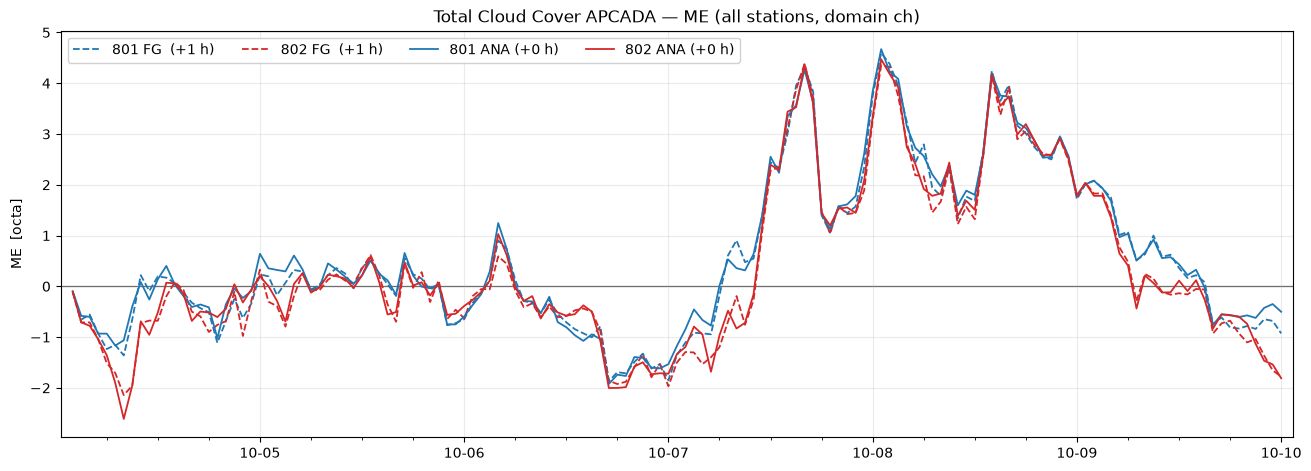

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.6), constrained_layout=True)

for label, wd, verdir, ltr, exp, kind in SERIES:
    df = data[label]
    ax.plot(df.index, df[SCORE], STYLE[kind], color=COLOR[exp],
            lw=1.3, label=label)

ax.axhline(0, color="0.35", lw=0.9, zorder=0)
ax.set_ylabel(f"{SCORE}  [{meta['Unit']}]")
ax.set_title(f"{meta['Description']} — {SCORE} "
             f"({'all stations, domain ch' if not SUBSET else f'station selection {SUBSET}'})")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=range(0, 24, 6)))
ax.grid(alpha=0.25, which="major")
ax.margins(x=0.01)
ax.legend(ncol=4, loc="upper left", framealpha=0.9)

FIGDIR.mkdir(exist_ok=True)
out = FIGDIR / f"bias_timeseries_{PARAM}{'_' + SUBSET if SUBSET else ''}.png"
fig.savefig(out, dpi=140, bbox_inches="tight")
print("written:", out)

### Mean bias per series

Collapsing the time series to one number per series makes the FG → analysis step easy to read off.

In [5]:
rows = []
for label, wd, verdir, ltr, exp, kind in SERIES:
    rows.append({"experiment": exp, "kind": kind, f"mean {SCORE}": data[label][SCORE].mean()})
tbl = pd.DataFrame(rows).pivot(index="experiment", columns="kind", values=f"mean {SCORE}")
tbl["ANA - FG"] = tbl["ANA"] - tbl["FG"]
tbl.round(4)

kind,ANA,FG,ANA - FG
experiment,,,
801,0.6128,0.5577,0.0551
802,0.3734,0.3314,0.0420


### All common parameters at once

`DD_10M` is included for completeness but its bias is **not** meaningful: wind direction is a
directional quantity, and the movero README notes under *Known issues* that the mean, spread and
standard deviation of model and observations are not computed in any special way for it. Read the
`DD_10M` panel as a placeholder, not as a result.

written: figures/bias_timeseries_all.png


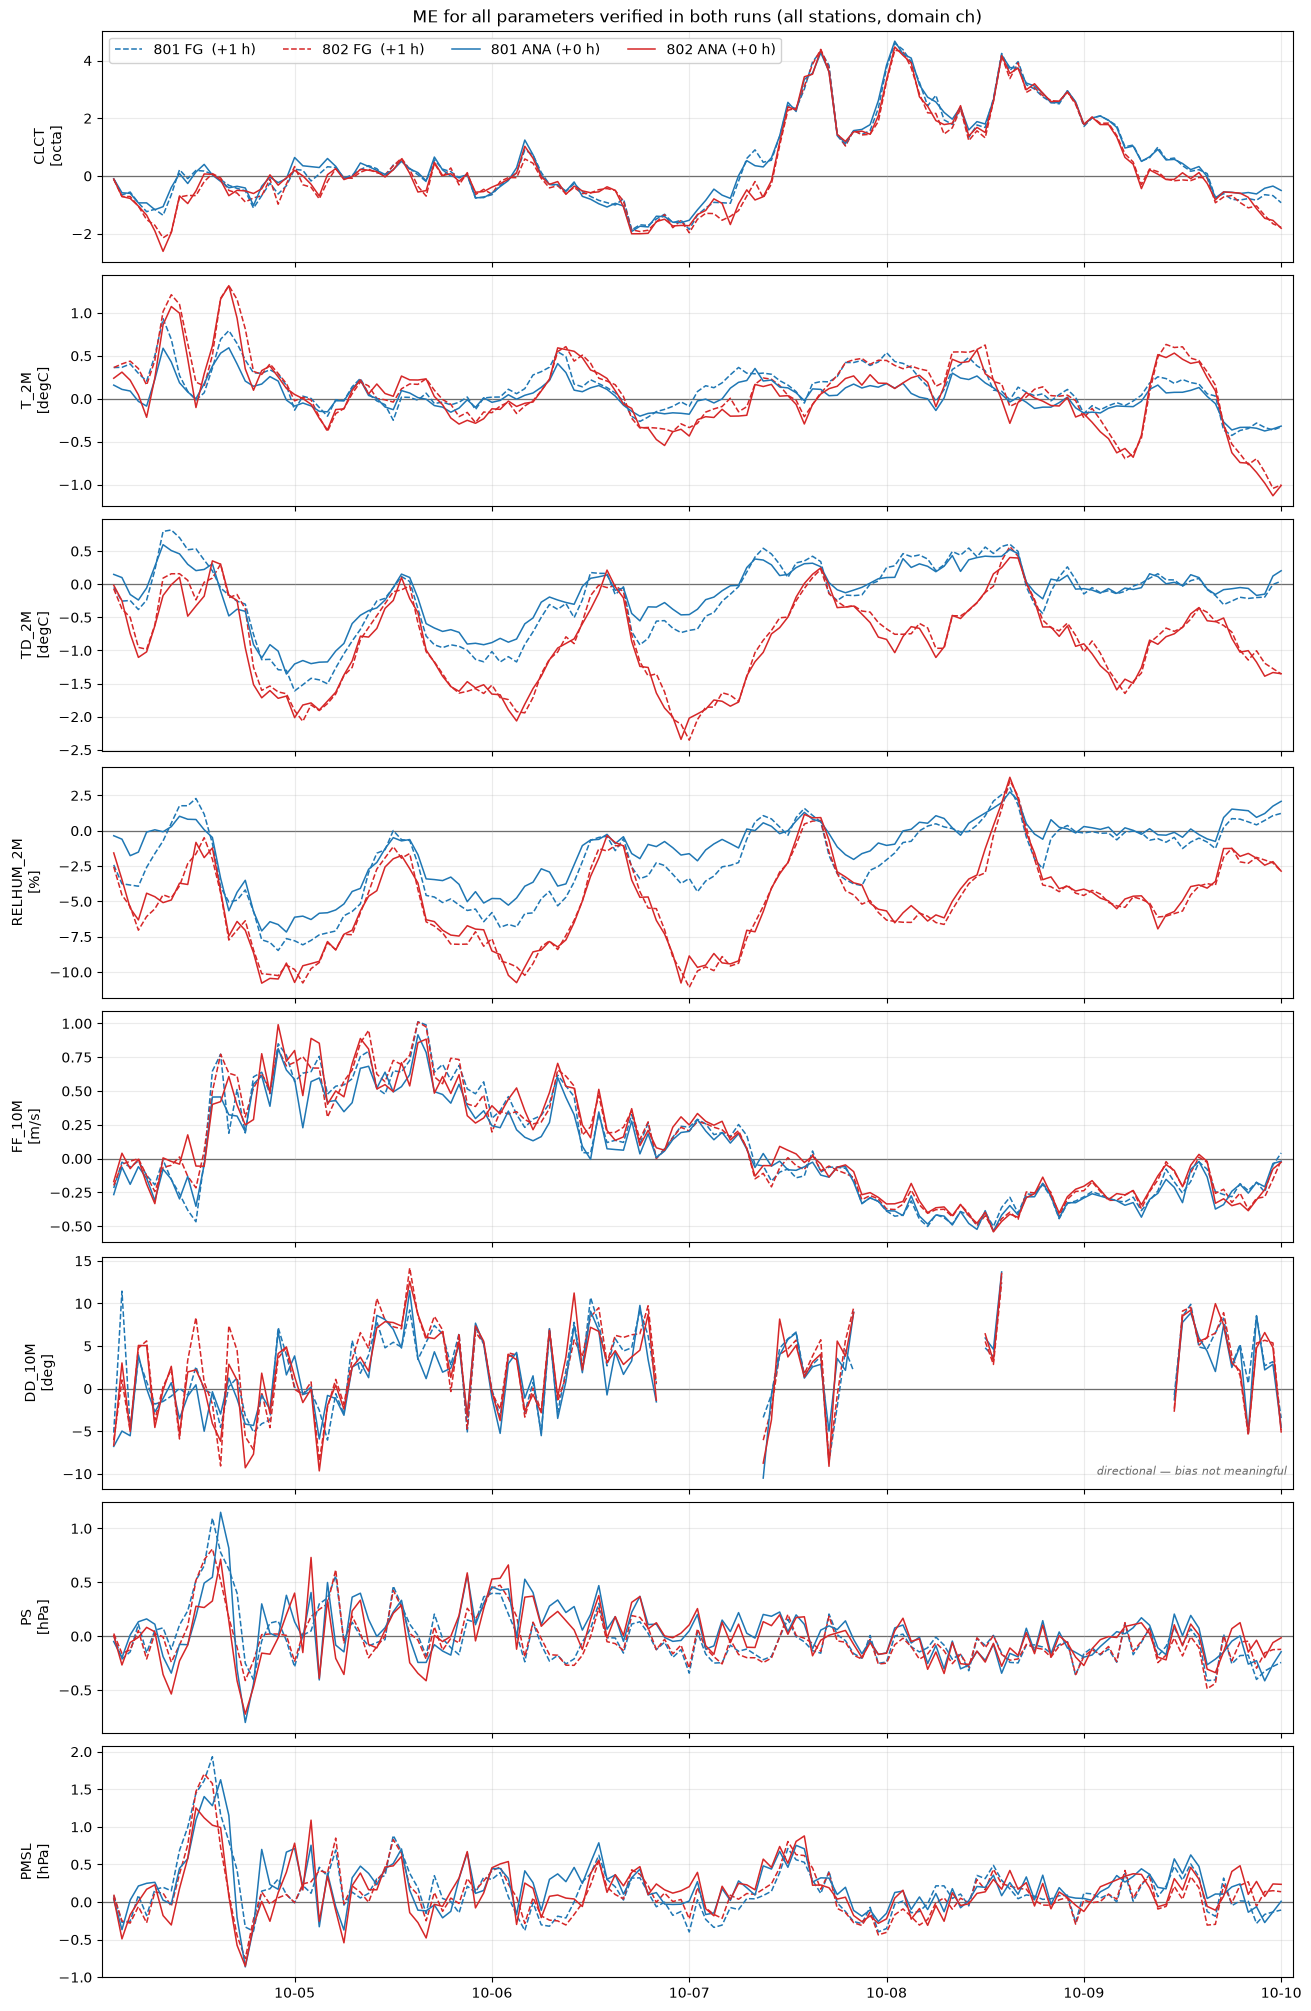

In [6]:
fig, axes = plt.subplots(len(COMMON_PARAMS), 1, figsize=(13, 2.5 * len(COMMON_PARAMS)),
                         sharex=True, constrained_layout=True)

for ax, param in zip(axes, COMMON_PARAMS):
    d, m = load_series(param, SUBSET, TRIM_TO_COMMON)
    for label, wd, verdir, ltr, exp, kind in SERIES:
        ax.plot(d[label].index, d[label][SCORE], STYLE[kind], color=COLOR[exp],
                lw=1.1, label=label)
    ax.axhline(0, color="0.35", lw=0.9, zorder=0)
    ax.set_ylabel(f"{param}\n[{m['Unit']}]")
    ax.grid(alpha=0.25)
    ax.margins(x=0.01)
    if param == "DD_10M":
        ax.text(0.995, 0.06, "directional — bias not meaningful", transform=ax.transAxes,
                ha="right", fontsize=8, style="italic", color="0.4")

axes[0].legend(ncol=4, loc="upper left", framealpha=0.9)
axes[0].set_title(f"{SCORE} for all parameters verified in both runs "
                  f"({'all stations, domain ch' if not SUBSET else f'station selection {SUBSET}'})")
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

out = FIGDIR / f"bias_timeseries_all{'_' + SUBSET if SUBSET else ''}.png"
fig.savefig(out, dpi=140, bbox_inches="tight")
print("written:", out)

---

**Extending this.** The same reader works on the other three score families movero writes next to
`time_scores`, so a diurnal cycle or a per-station map is a one-line change to the filename:

- `daytime_scores<ltr>_<PARAM>.dat` — scores composited by hour of day
- `station_scores<ltr>_<PARAM>.dat` — one value per station
- `total_scores<ltr>_<PARAM>.dat` — a single number per score over the whole period

Categorical scores are in the same tables as extra columns, named with the threshold in
parentheses — e.g. `FBI(2.5)`, `POD(6.5)` for CLCT. Set `SCORE` accordingly. Note that the two runs
were configured with different CLCT thresholds histories, so check the column names in
`data[label].columns` before selecting one.